In [9]:
# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import math
import glob
from scipy.optimize import curve_fit
import seaborn as sns
%matplotlib inline

/tmp/ipykernel_15855/1667028254.py:13: RuntimeWarning: invalid value encountered in log10
  logb = np.log10(b)


Text(0, 0.5, 'log r0')

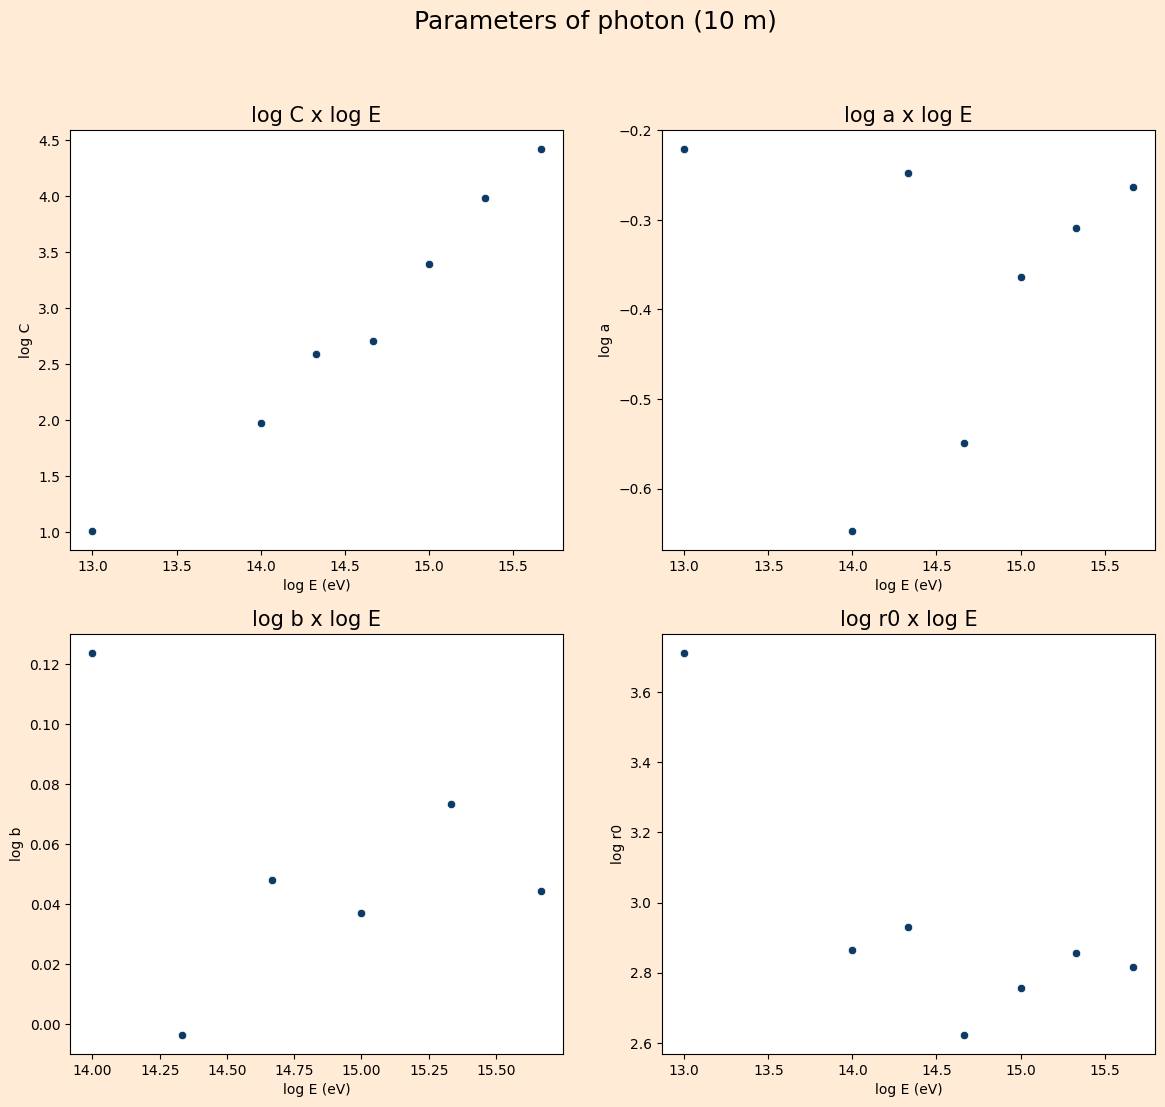

In [10]:
# Fóton

C = [10.27,94.6,386.3,511.2,2464,9658,2.662E4]
a = [0.6014,0.2255,0.5653,0.2825,0.4326,0.4909,0.5449]
b = [-0.148,1.33,0.9922,1.117,1.089,1.184,1.108]
r0 = [5160,732,850.5,420,571,719,654.9]
E = [1E13,1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.000813458,0.0343635,0.190061,0.416537,1.53537,4.63964,15.2]


logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


/tmp/ipykernel_15855/3121855694.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[8.80065239e-19 1.00598598e-01]
[1.95626644 2.44419351 2.93452919 3.4239879  3.91191497 4.40225065]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.975891,14.0,14.013371,0.095506
2.586925,14.332438,14.429685,0.678508
2.708591,14.666518,14.51258,1.049589
3.391641,15.0,14.977961,0.146927
3.984887,15.332438,15.382157,0.324267
4.425208,15.666518,15.68216,0.09984


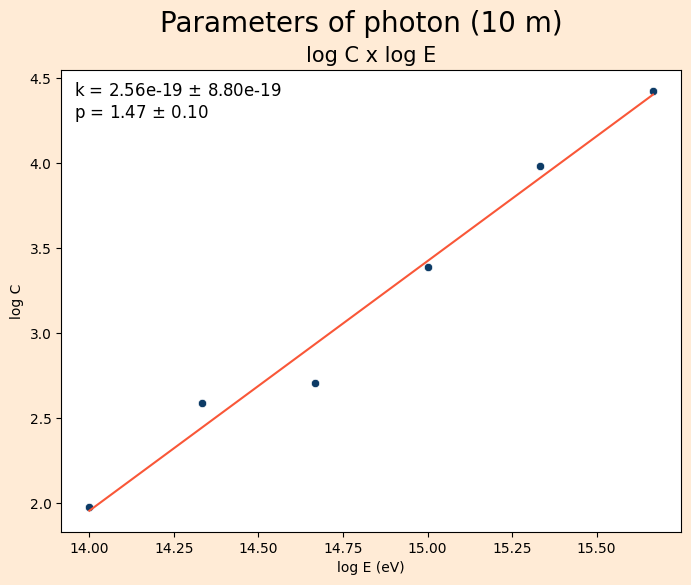

In [11]:
# Fit do fóton

C = [94.6,386.3,511.2,2464,9658,2.662E4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_15855/105866701.py:62: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[4.04624474e-15 2.42045339e-02]


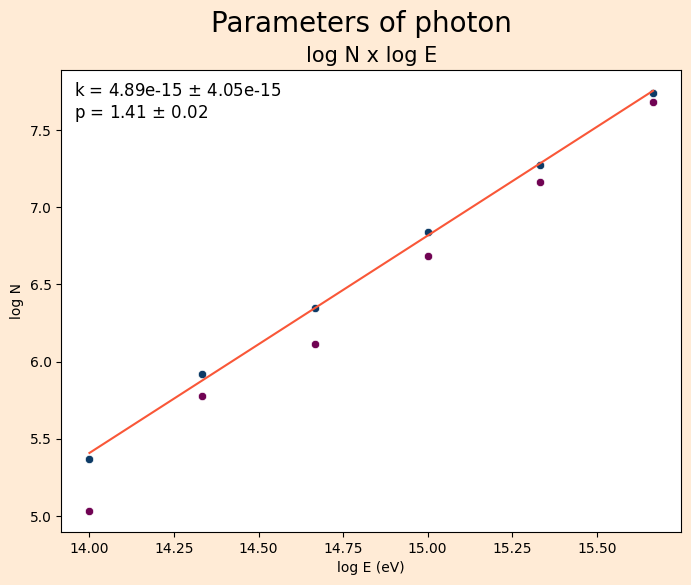

In [12]:
# Relação entre C e o número total de partículas (N)

# Fóton


C = [94.6,386.3,511.2,2464,9658,2.662E4]
a = [0.2255,0.5653,0.2825,0.4326,0.4909,0.5449]
b = [1.33,0.9922,1.117,1.089,1.184,1.108]
r0 = [732,850.5,420,571,719,654.9]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0343635,0.190061,0.416537,1.53537,4.63964,15.2]
N_t = []
N_s = []


for i  in range(len(C)):
    aux = D[i]*math.pi*1000**2
    N_s.append(aux)  

output_path = '/home/orfei/mestrado/progs/lateral_distribution/photon/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


<AxesSubplot: title={'center': 'Relative Error'}, xlabel='log E (eV)', ylabel='log N'>

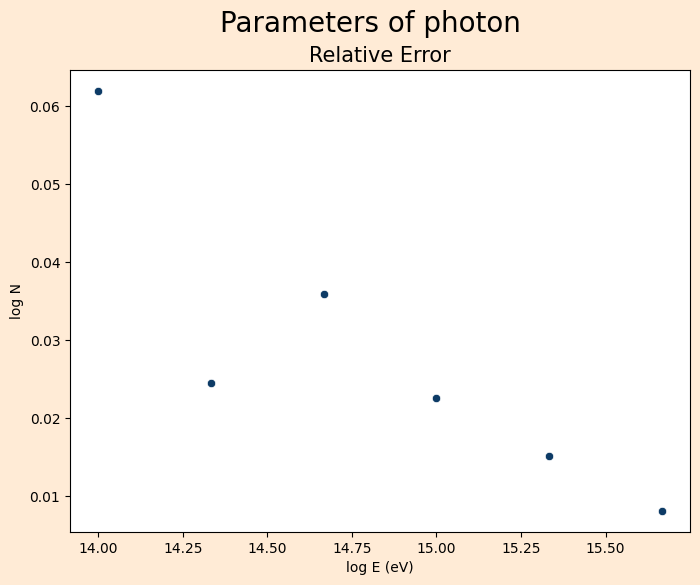

In [13]:
relative_error = abs((logN_s-logN))/logN

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('Relative Error', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')

sns.scatterplot(x = logE, y = relative_error, color = '#0D3B66', ax = ax)

Text(0, 0.5, 'log r0')

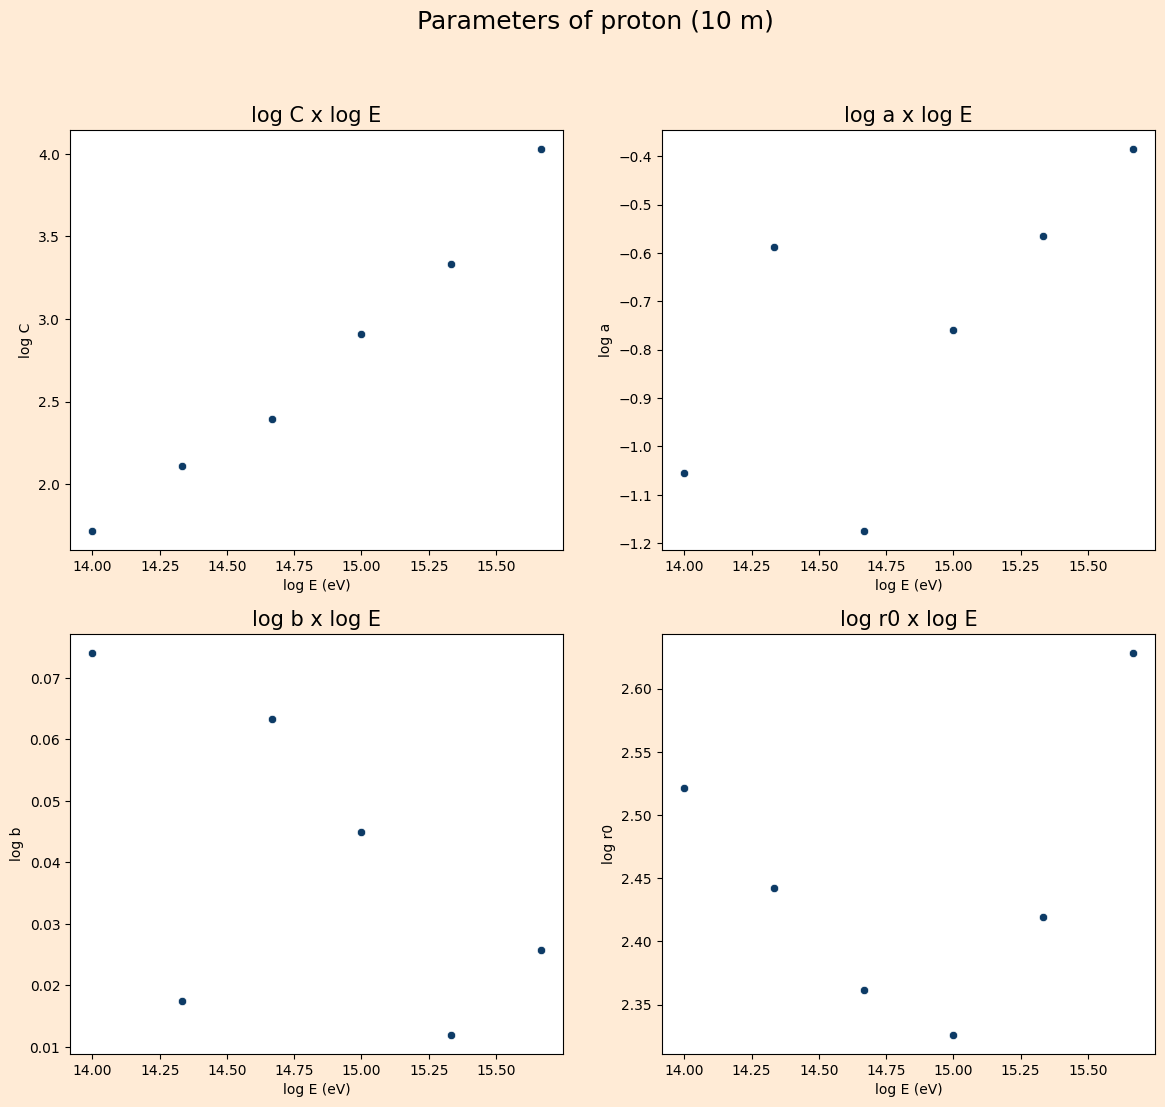

In [14]:
# Próton


C = [52.43,129.8,246.8,810.3,2163,1.071E4]
a = [ 0.08821,0.2581, 0.06696,0.1737,0.2723,0.4124]
b = [1.186,1.041, 1.157,1.109,1.028,1.061]
r0 = [331.9,277,229.9, 212,262.6,424.9]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0555641,0.18428,0.41216,1.46918,3.2367,9.08204]

logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


/tmp/ipykernel_15855/4055021986.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.73189238e-17 9.09588519e-02]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.71958,14.0,14.069084,0.49346
2.113275,14.332438,14.361011,0.199359
2.392345,14.666518,14.567944,0.672103
2.908646,15.0,14.950784,0.328106
3.335057,15.332438,15.26697,0.426992
4.029789,15.666518,15.782119,0.737885


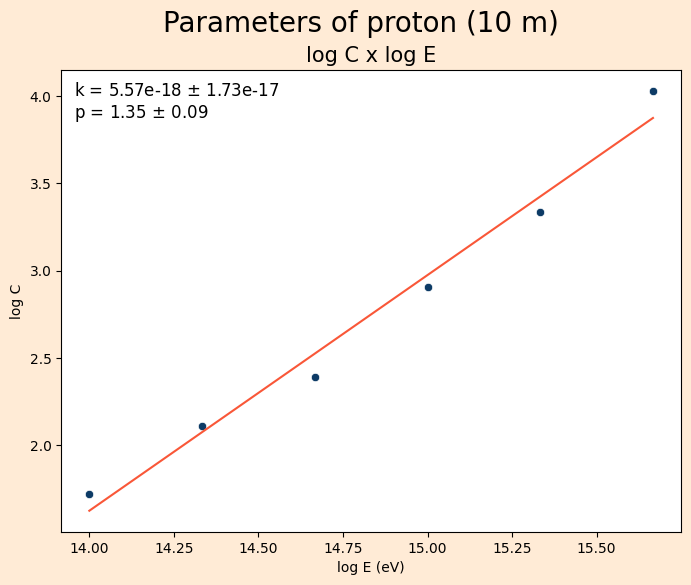

In [15]:
# Fit do próton

C = [52.43,129.8,246.8,810.3,2163,1.071E4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_15855/1071045743.py:63: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[6.43575901e-12 1.80286337e-02]


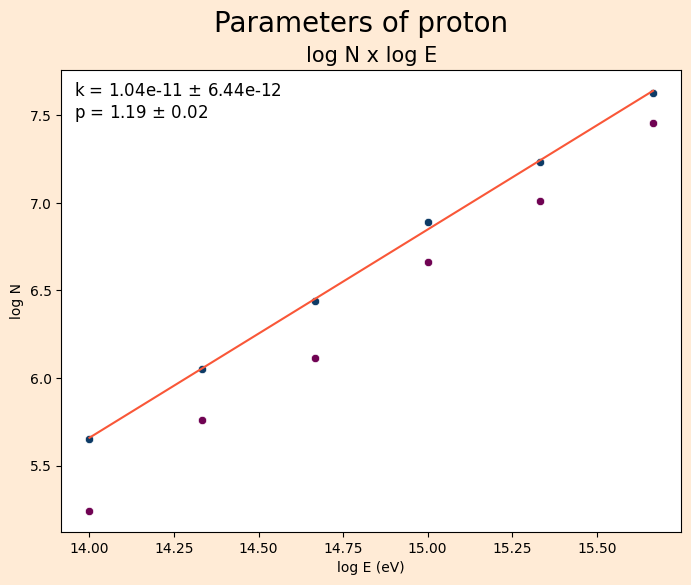

In [16]:
# Relação entre C e o número total de partículas (N)

# Próton

C = [52.43,129.8,246.8,810.3,2163,1.071E4]
a = [ 0.08821,0.2581, 0.06696,0.1737,0.2723,0.4124]
b = [1.186,1.041, 1.157,1.109,1.028,1.061]
r0 = [331.9,277,229.9, 212,262.6,424.9]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0555641,0.18428,0.41216,1.46918,3.2367,9.08204]
N_t = []
N_s = []


for i  in range(len(C)):
    aux = D[i]*math.pi*1000**2
    N_s.append(aux) 


output_path = '/home/orfei/mestrado/progs/lateral_distribution/proton/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

<AxesSubplot: title={'center': 'Relative Error'}, xlabel='log E (eV)', ylabel='log N'>

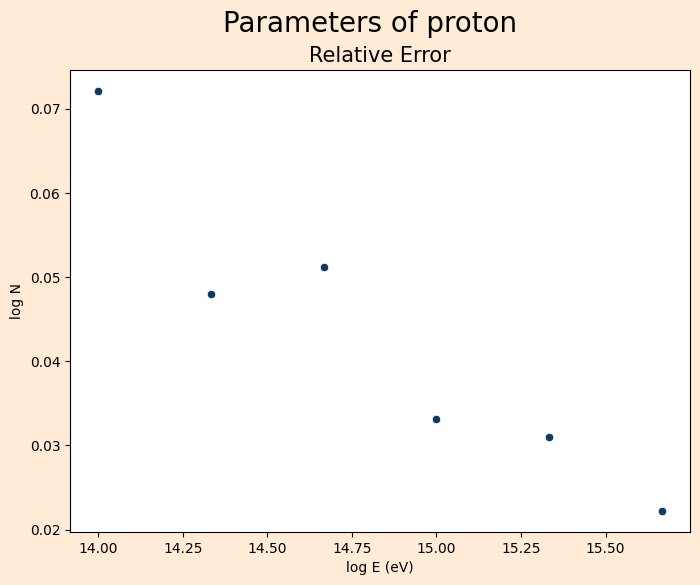

In [17]:
relative_error = abs((logN_s-logN))/logN

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 20)
#fig.tight_layout()


ax.set_title('Relative Error', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')

sns.scatterplot(x = logE, y = relative_error, color = '#0D3B66', ax = ax)

/tmp/ipykernel_15855/93939246.py:11: RuntimeWarning: invalid value encountered in log10
  loga = np.log10(a)
/tmp/ipykernel_15855/93939246.py:12: RuntimeWarning: invalid value encountered in log10
  logb = np.log10(b)


Text(0, 0.5, 'log r0')

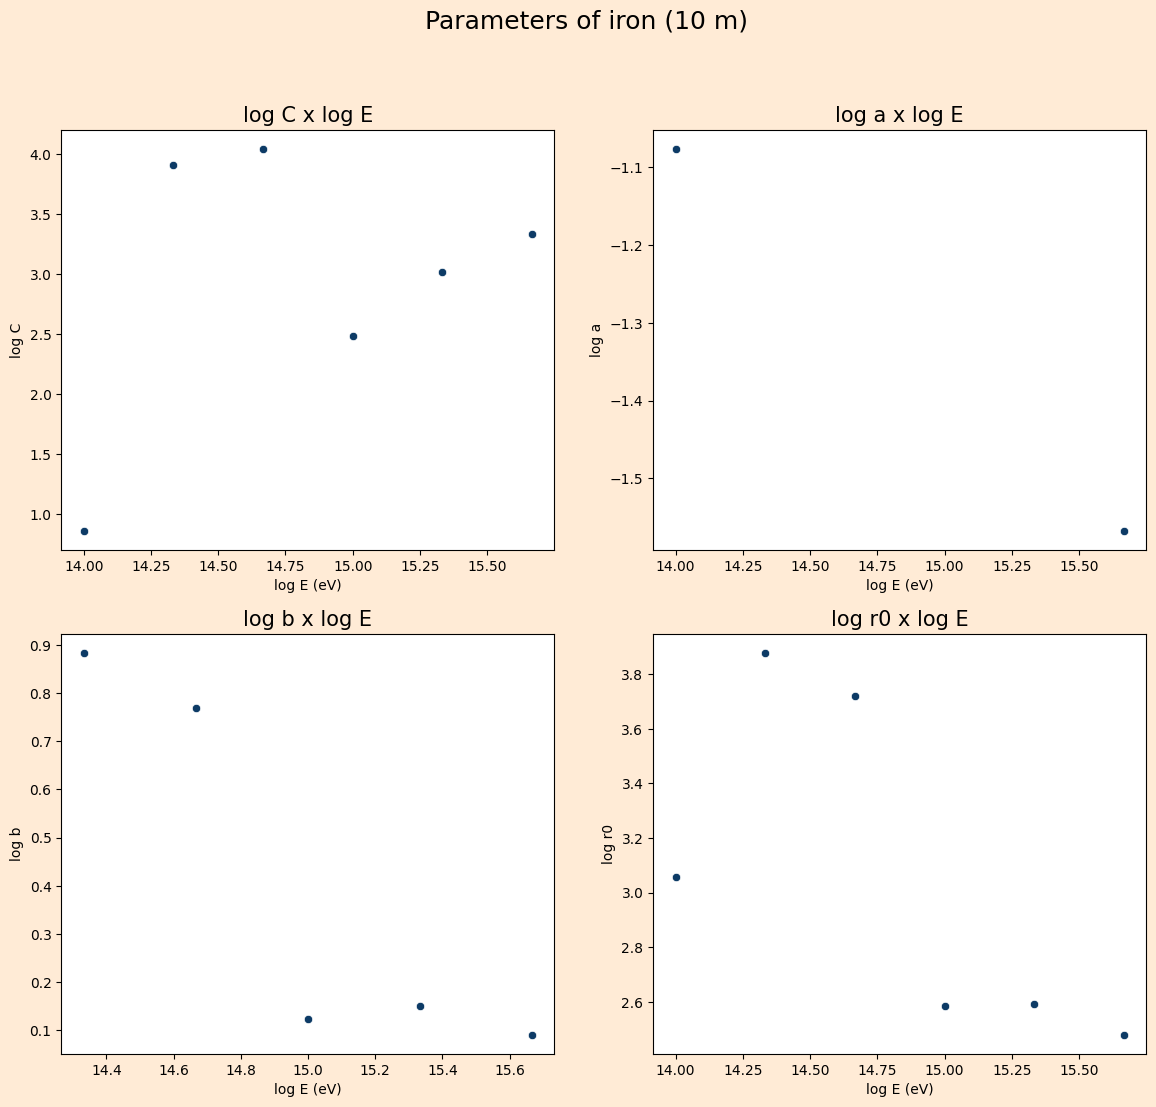

In [18]:
# Ferro

C = [7.297,7999,1.1E4,304.4,1037,2150]
a = [0.08388,-0.2952,-0.1341,-0.1202,-0.0946,0.02709]
b = [-0.2119,7.646,5.872,1.331,1.416,1.234]
r0 = [1144,7560,5231,383,389.6,302.1]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.00694233,0.0222677,0.0739094,0.265782,0.767331,2.41884]

logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala

/tmp/ipykernel_15855/2749951513.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.22547860e-06 8.69530246e-01]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
0.863144,14.0,11.849425,15.361252
3.903036,14.332438,16.216728,13.147024
4.041393,14.666518,16.4155,11.924999
2.483445,15.0,14.177252,5.484986
3.015779,15.332438,14.942037,2.546243
3.332438,15.666518,15.396971,1.720529


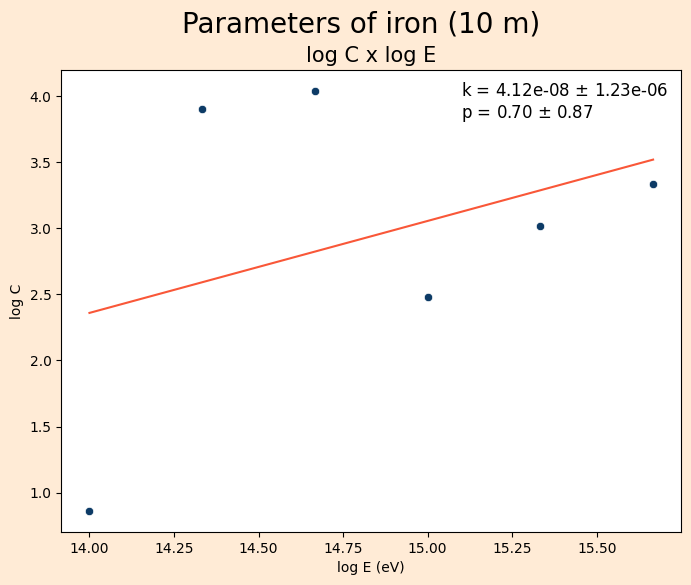

In [19]:
# Fit do ferro

C = [7.297,7999,1.1E4,304.4,1037,2150]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_15855/3296478044.py:63: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.72017716e-11 1.62789612e-02]


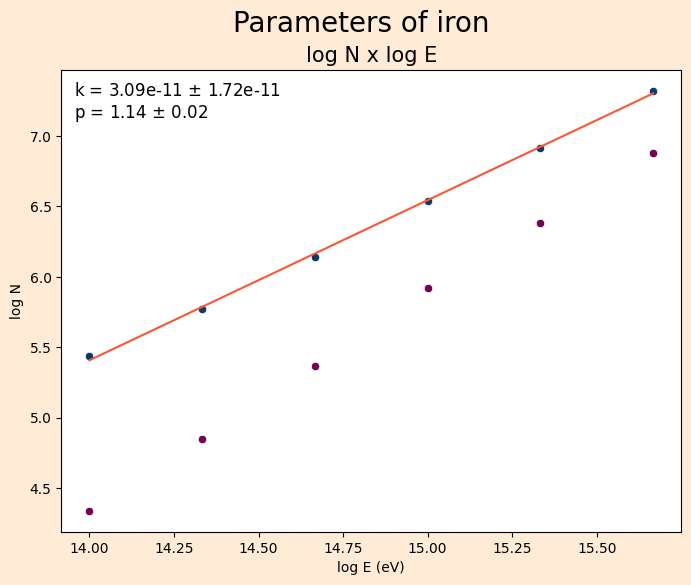

In [20]:
# Relação entre C e o número total de partículas (N)

# Ferro

C = [7.297,7999,1.1E4,304.4,1037,2150]
a = [0.08388,-0.2952,-0.1341,-0.1202,-0.0946,0.02709]
b = [-0.2119,7.646,5.872,1.331,1.416,1.234]
r0 = [1144,7560,5231,383,389.6,302.1]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.00694233,0.0222677,0.0739094,0.265782,0.767331,2.41884]
N_t = []
N_s = []


for i  in range(len(C)):
    aux = D[i]*math.pi*1000**2
    N_s.append(aux) 

output_path = '/home/orfei/mestrado/progs/lateral_distribution/iron/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df


logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

<AxesSubplot: title={'center': 'Relative Error'}, xlabel='log E (eV)', ylabel='log N'>

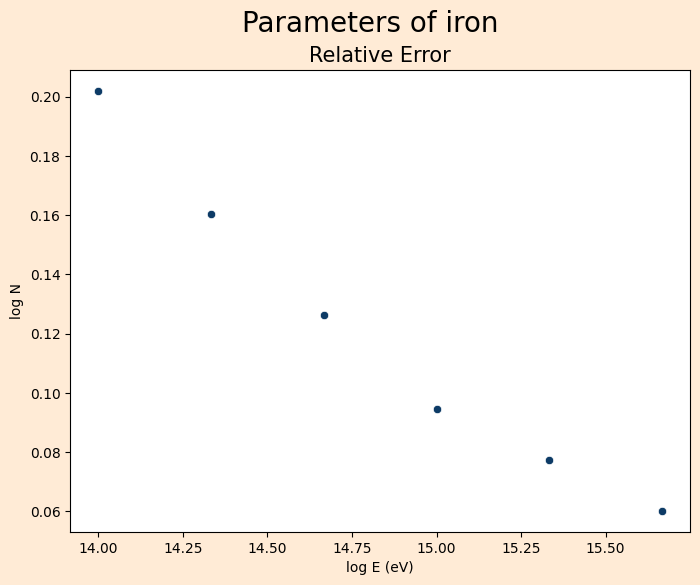

In [21]:
relative_error = abs((logN_s-logN))/logN

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 20)
#fig.tight_layout()


ax.set_title('Relative Error', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')

sns.scatterplot(x = logE, y = relative_error, color = '#0D3B66', ax = ax)